In [118]:

import math
import warnings
from typing import Any, Dict, Tuple

import numpy as np

import jax
from jax import Array
from jax.tree_util import Partial
from jax import numpy as jnp

import dynamiqs as dq

from matplotlib import pyplot as plt

from blueprint.qubits import TunableTransmon
from blueprint.util.quantum import expectation_value
from blueprint.util.index import get_max_overlap_inds


jax.config.update("jax_enable_x64", True)  # Double

In [2]:
def readout_pulse(
    t: float,
    drive_amplitude: float | Array,
    drive_frequency: float | Array,
) -> float | Array: 
    amplitude = drive_amplitude * jnp.cos(drive_frequency * t)
    return amplitude

In [3]:
def get_hamiltonian(qubit):
    qubit_hamiltonian = qubit.get_hamiltonian()
    hamiltonian = dq.constant(qubit_hamiltonian)

    drive_terms = qubit.get_drive_hamiltonian_terms()
    for prefactor, operator in drive_terms:
        drive_hamiltonian = dq.modulated(prefactor, operator)
        hamiltonian += drive_hamiltonian

    return hamiltonian

In [4]:
def get_figsize(
    columns: int = 1, fig_width : float | None = None, fig_height: float | None = None, width_scale: float = 1.0, height_scale: float = 1.0
) -> Tuple[float, float]:
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    MAX_HEIGHT = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = (
            3.4 if columns == 1 else 7
        )  # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > MAX_HEIGHT:
        warnings.warn(
            "Figure height {} is too large, setting to {}"
            "inches instead".format(fig_height, MAX_HEIGHT)
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps",
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

Define the units

In [153]:
# units
GHz = 2 * math.pi
MHz = 2 * 1e-3 * math.pi

flux_quantum = 2 * math.pi

Create the qubit, a transmon in this case.

In [154]:
QUBIT_LABEL: str = "transmon"
CHARGING_ENERGY: float = 220 * MHz
ENERGY_RATIO: float = 110
JOSEPHSON_ENERGY: float = ENERGY_RATIO * CHARGING_ENERGY
OFFSET_CHARGE: float = 0.0
ASYMMETRY: float = 0.0
EXT_FLUX: float = 0.0 * flux_quantum
CHARGE_CUTOFF: int = 500
QUBIT_DIM: int = 25

qubit = TunableTransmon(
    label=QUBIT_LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
)

qubit.diagonalize(truncated_dim=QUBIT_DIM)

Create the resonator to which the qubit is coupled to

In [155]:
RES_COUPLING_STRENGTH: float = 120 * MHz

DRIVE_FREQUENCY: float = 7.515 * GHz
DRIVE_PERIOD: float = 2 * math.pi / DRIVE_FREQUENCY

In [156]:
MAX_NUM_PHOTONS: int = 300

MIN_DRIVE_AMP = 0.0
MAX_DRIVE_AMP = 2 * RES_COUPLING_STRENGTH * math.sqrt(MAX_NUM_PHOTONS)
DRIVE_AMP_STEP = 5 * MHz

In [157]:
drive_amplitudes = jnp.arange(MIN_DRIVE_AMP, MAX_DRIVE_AMP, DRIVE_AMP_STEP)
res_photons = (drive_amplitudes / (2 * RES_COUPLING_STRENGTH)) ** 2

num_times = 100
save_times = jnp.linspace(0, DRIVE_PERIOD, num_times)

In [158]:
partial_pulse = Partial(
    readout_pulse,
    drive_amplitude=drive_amplitudes,
    drive_frequency=DRIVE_FREQUENCY,
)

qubit.add_charge_drive(label="readout_drive", charge_pulse=partial_pulse)

In [159]:
hamiltonian = get_hamiltonian(qubit)

In [160]:
method = dq.method.Tsit5(rtol=1e-8, atol=1e-8, max_steps=1000000)
options = dq.Options(progress_meter=True)

In [ ]:
result = dq.floquet(hamiltonian, DRIVE_PERIOD, save_times, method = method, options = options)

|          |   0.0% ◆ elapsed 0.00ms ◆ remaining ?

|██████████| 100.0% ◆ elapsed 30.55s ◆ remaining 0.00ms  


In [162]:
modes = jnp.squeeze(result.modes.to_jax())
modes = jnp.transpose(modes, (0, 1, 3, 2))

final_modes = modes[:, -1]
quasienergies = result.quasienergies

# Label the modes and quasienergies

In [163]:
def assign_branch_inds(prev_modes: Array, next_modes: Array) -> Tuple[Array, Array]:
    """Sorts the modes based on the overlap with the previous modes."""
    sort_inds = get_max_overlap_inds(prev_modes, next_modes)
    sorted_modes = next_modes[:, sort_inds]
    return sorted_modes, sort_inds
    

def get_branch_inds(modes: Array, states: Array) -> Array:
    _, inds = jax.lax.scan(assign_branch_inds, states, modes)
    return inds

Perform the floquet branch analysis

In [164]:
_, qubit_states = qubit.get_eigenstates()
inds = get_branch_inds(final_modes, qubit_states.astype(complex))

branch_quasienergies = jnp.take_along_axis(quasienergies, inds, axis=1)


exp_inds = jnp.expand_dims(inds, axis=1)
branches = jnp.take_along_axis(final_modes, exp_inds, axis=2)

number_op = qubit.get_number_op()

def get_branch_excitations(number_op: Array, inst_branches: Array) -> Tuple[Array, Array]:
    """Calculates the expectation value of the number operator for each branch."""
    branch_excitations = jnp.real(expectation_value(inst_branches, number_op))
    return number_op, branch_excitations

_, branch_excitations = jax.lax.scan(get_branch_excitations, number_op, branches)

Plot the results

In [328]:
offset = 0.5 * DRIVE_FREQUENCY
offset_quasienergies = -branch_quasienergies % DRIVE_FREQUENCY - offset

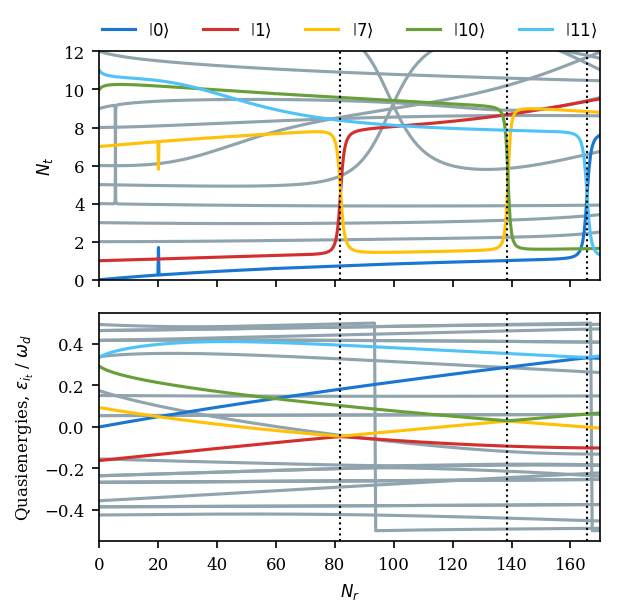

In [329]:
figsize = get_figsize(width_scale=1.25, height_scale=2)  # Use the recommended figure size for two-column figures
rc_params = get_rc_params()  # Use the recommended rc params

highlighted_states = (0, 1, 7, 10, 11)
colors = ["#1976d2", "#d32f2f", "#ffc107", "#689f38", "#4fc3f7"]
default_color = "#90a4ae"

resonance_populations = (81.6, 138.6, 165.6) # Resonator populations at which resonances occur
num_states = 25 # How many states to plot
states = tuple(range(num_states + 1))
background_states = (state for state in states if state not in highlighted_states)

with plt.rc_context(rc=rc_params):
    fig, axs = plt.subplots(nrows=2, sharex=True, figsize=figsize, tight_layout=True, dpi=150)
    exc_ax, energy_ax = axs

    for state in background_states:
        excitations = branch_excitations[:, state]
        energies = offset_quasienergies[:, state] / DRIVE_FREQUENCY

        exc_ax.plot(res_photons, excitations, color=default_color)
        energy_ax.plot(res_photons, energies, color=default_color)

    for state in highlighted_states:
        state_ind = highlighted_states.index(state)
        color = colors[state_ind]
        label = f"$\\left\\vert {{{state}}} \\right\\rangle$"

        excitations = branch_excitations[:, state]
        energies = offset_quasienergies[:, state] / DRIVE_FREQUENCY
        
        exc_ax.plot(res_photons, excitations, color=color, label=label)
        energy_ax.plot(res_photons, energies, color=color, label=label)

    for res_population in resonance_populations:
        exc_ax.axvline(res_population, color="black", linestyle=":", linewidth=1)
        energy_ax.axvline(res_population, color="black", linestyle=":", linewidth=1)
    

    exc_ax.legend(ncols=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.2))

    exc_ax.set_ylim(0, 12)
    exc_ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
    exc_ax.set_ylabel(r"$N_{t}$")

    energy_ax.set_ylim(-0.55, 0.55)
    energy_ax.set_yticks([-0.4, -0.2, 0, 0.2, 0.4])
    energy_ax.set_ylabel(r"Quasienergies, $\epsilon_{i_{t}}$ / $\omega_d$")

    energy_ax.set_xlim(0, 170)
    energy_ax.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160])
    energy_ax.set_xlabel(r"$N_{r}$")

plt.show()